In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [19]:
df = pd.read_csv('oil_gas_lithology_classification_dataset.csv')
X = dataset.iloc[:, [2,3,4,5]].values
df

,Well_ID,Depth_ft,Gamma_Ray_API,Resistivity_Ohm_m,Density_gcc,Neutron_Porosity,Lithology
0,WELL_001,6560.19,60.96,125.85,2.412,0.246,Limestone
1,WELL_002,6834.05,37.79,220.42,2.134,0.124,Sandstone
2,WELL_003,11118.53,37.42,103.47,2.042,0.123,Sandstone
3,WELL_004,12851.76,49.86,107.73,2.345,0.136,Limestone
4,WELL_005,11075.45,116.01,3.73,2.567,0.334,Shale
...,...,...,...,...,...,...,...
495,WELL_496,14706.77,48.92,79.95,2.314,0.202,Limestone
496,WELL_497,9227.29,32.70,143.03,2.251,0.171,Sandstone
497,WELL_498,9830.40,98.38,3.02,2.550,0.303,Shale
498,WELL_499,11036.37,25.78,139.84,2.197,0.142,Sandstone


In [20]:
print(df.shape)

(500, 7)


In [25]:
df.drop(columns=['Well_ID', 'Depth_ft','Lithology'], inplace=True)

In [26]:
df.describe()

,Gamma_Ray_API,Resistivity_Ohm_m,Density_gcc,Neutron_Porosity
count,500.000000,500.00000,500.000000,500.000000
mean,64.608020,115.50412,2.367174,0.215666
std,35.149916,77.32997,0.184891,0.083076
min,9.970000,0.50000,1.964000,0.061000
25%,37.737500,11.33500,2.206000,0.150000
50%,53.960000,134.03500,2.364500,0.194000
75%,94.905000,171.83000,2.534250,0.287250
max,149.720000,273.37000,2.754000,0.406000


In [28]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Scale features (mandatory for K-Means — distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)
 
print("Dataset shape  :", df.shape)
print("Features used  :", df.columns.tolist())


Dataset shape  : (500, 4)
Features used  : ['Gamma_Ray_API', 'Resistivity_Ohm_m', 'Density_gcc', 'Neutron_Porosity']


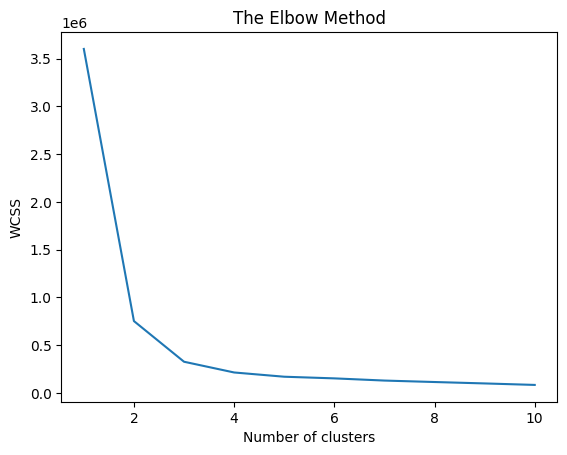

In [29]:
#Using the elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [30]:
#Training the K-Means model on the dataset
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

  K =  2   Silhouette Score = 0.6616
  K =  3   Silhouette Score = 0.5305
  K =  4   Silhouette Score = 0.4415
  K =  5   Silhouette Score = 0.3175
  K =  6   Silhouette Score = 0.2270
  K =  7   Silhouette Score = 0.2229
  K =  8   Silhouette Score = 0.2189
  K =  9   Silhouette Score = 0.2105
  K = 10   Silhouette Score = 0.2143

Best K by Silhouette Score: 2


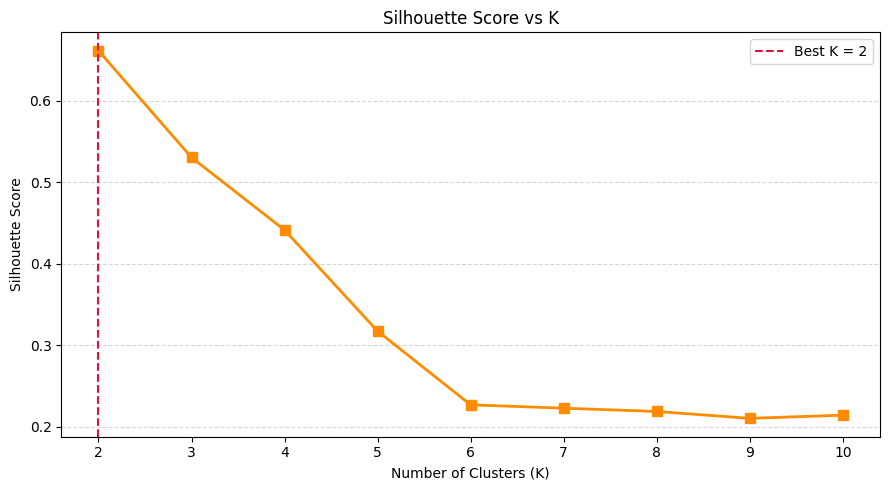

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
 
k_range  = range(2, 11)
sil_scores = []
 
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  K = {k:2d}   Silhouette Score = {score:.4f}")
 
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nBest K by Silhouette Score: {best_k}")
 
# Plot silhouette scores
plt.figure(figsize=(9, 5))
plt.plot(k_range, sil_scores, marker='s', color='darkorange',
         linewidth=2, markersize=7)
plt.axvline(best_k, color='crimson', linestyle='--',
            label=f'Best K = {best_k}')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(k_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("kmeans_silhouette.png", dpi=150)
plt.show()
 


In [33]:
# Set best_k from Step 1 (elbow) confirmed by Step 2 (silhouette)
best_k = 3                   # <-- update to your chosen K
 
km_final = KMeans(
    n_clusters=best_k,
    init='k-means++',        # k-means++ for smart centroid seeding
    n_init=10,               # Repeat 10 times; keep run with lowest inertia
    max_iter=300,            # Max iterations per run
    tol=1e-4,                # Convergence tolerance
    random_state=42
)
km_final.fit(X_scaled)
 
# Assign cluster labels back to original dataframe
df['Cluster'] = km_final.labels_
 
print(f"Final K           : {best_k}")
print(f"Final Inertia     : {km_final.inertia_:.4f}")
print(f"Iterations taken  : {km_final.n_iter_}")
print(f"\nCluster Counts:")
print(df['Cluster'].value_counts().sort_index())


Final K           : 3
Final Inertia     : 265.1442
Iterations taken  : 3

Cluster Counts:
Cluster
0    143
1    186
2    171
Name: count, dtype: int64


In [34]:
# 4a. Mean of every feature per cluster
cluster_means = df.groupby('Cluster').mean().round(3)
print("\n--- Cluster Means (original scale) ---")
print(cluster_means.to_string())



--- Cluster Means (original scale) ---
         Gamma_Ray_API  Resistivity_Ohm_m  Density_gcc  Neutron_Porosity
Cluster                                                                 
0              114.747              8.112        2.604             0.329
1               34.257            184.900        2.174             0.142
2               55.692            129.828        2.380             0.201


In [35]:
# 4b. Full descriptive stats per cluster
print("\n--- Cluster Descriptive Statistics ---")
for c in sorted(df['Cluster'].unique()):
    print(f"\n  Cluster {c}  (n = {(df['Cluster']==c).sum()})")
    print(df[df['Cluster']==c].describe().round(3).to_string())



--- Cluster Descriptive Statistics ---

  Cluster 0  (n = 143)
       Gamma_Ray_API  Resistivity_Ohm_m  Density_gcc  Neutron_Porosity  Cluster
count        143.000            143.000      143.000           143.000    143.0
mean         114.747              8.112        2.604             0.329      0.0
std           15.346              3.087        0.059             0.040      0.0
min           75.940              0.500        2.492             0.213      0.0
25%          104.765              5.965        2.558             0.302      0.0
50%          115.420              8.370        2.602             0.331      0.0
75%          125.740              9.960        2.648             0.356      0.0
max          149.720             16.810        2.754             0.406      0.0

  Cluster 1  (n = 186)
       Gamma_Ray_API  Resistivity_Ohm_m  Density_gcc  Neutron_Porosity  Cluster
count        186.000            186.000      186.000           186.000    186.0
mean          34.257            

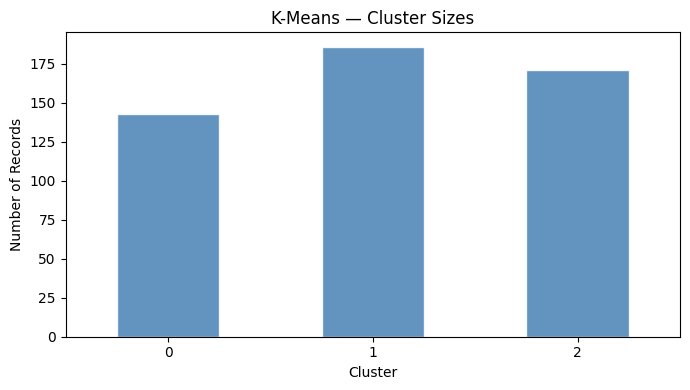

In [36]:
#4c. Cluster size bar chart
plt.figure(figsize=(7, 4))
df['Cluster'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', alpha=0.85, edgecolor='white')
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.title("K-Means — Cluster Sizes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("kmeans_cluster_sizes.png", dpi=150)
plt.show()


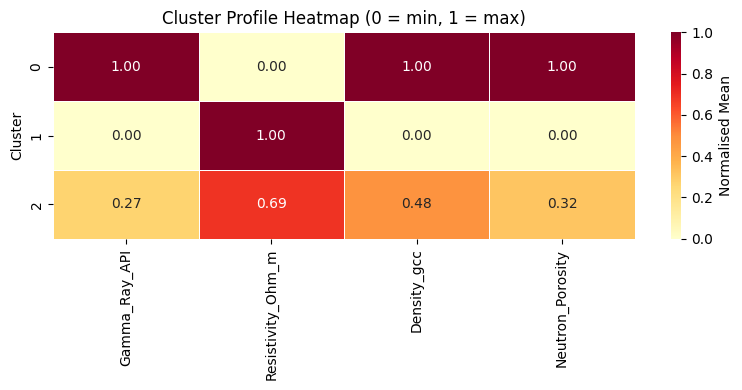

In [38]:
# 4d. Heatmap of cluster means (normalised for easy comparison)
norm_means = (cluster_means - cluster_means.min()) / (
              cluster_means.max() - cluster_means.min())
 
plt.figure(figsize=(max(8, len(df.columns)*0.8), 4))
sns.heatmap(norm_means, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={'label': 'Normalised Mean'})
plt.title("Cluster Profile Heatmap (0 = min, 1 = max)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("kmeans_cluster_heatmap.png", dpi=150)
plt.show()
 


In [ ]:
#High GammaR means  *clay-rich rock, * radioactive minerals * shale dominance 
# low resistivity * conductive fluid (more water, less hydrocarbon ) 
# High density * Compacted shale * clay-rich intervals 
# high Neuron porosity * bound water in clays * hydrogen-rich mineral
# CLUSTER 1 * High resistivity means Hydrocarbon saturation 
# low Neutron porosity means  gas zone 
#CLUSTER 2 
# MIX FACIE OR TRANSITION ZONE 

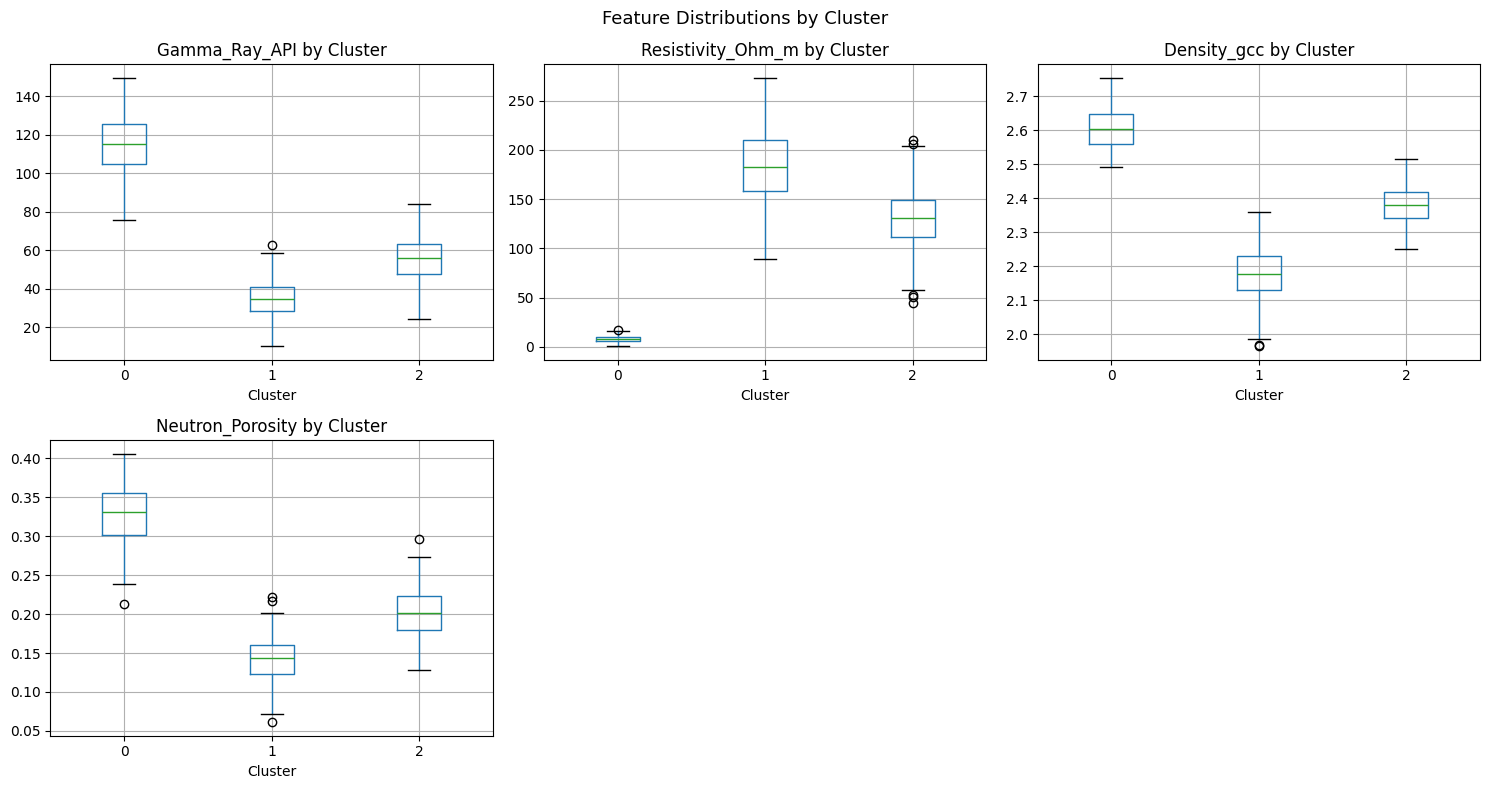

In [39]:
# 4e. Box plots — each feature by cluster
feature_cols = [c for c in df.columns if c != 'Cluster']
n_feat = len(feature_cols)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols
 
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_feat > 1 else [axes]
 
for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Cluster', ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
 
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Feature Distributions by Cluster", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_boxplots_by_cluster.png", dpi=150)
plt.show()
 


In [41]:
from sklearn.decomposition import PCA
 


In [42]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)


C:\Users\USER\AppData\Local\Temp\ipykernel_22156\1629146418.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('Set2', best_k)


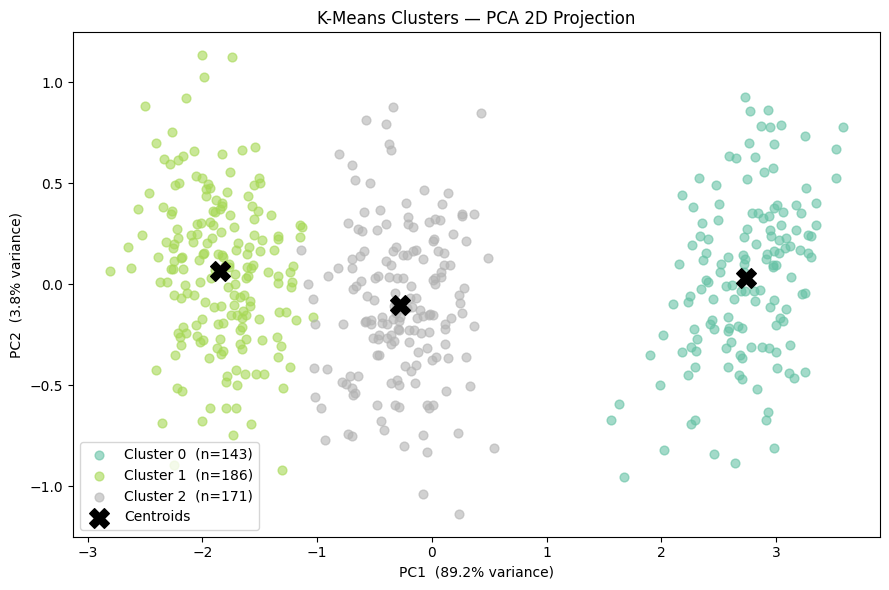

In [43]:
centroids_2d = pca2.transform(km_final.cluster_centers_)
 
plt.figure(figsize=(9, 6))
palette = plt.cm.get_cmap('Set2', best_k)
for c in range(best_k):
    mask = df['Cluster'] == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=palette(c), alpha=0.6, s=40,
                label=f'Cluster {c}  (n={mask.sum()})')
 
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            marker='X', s=200, c='black',
            zorder=5, label='Centroids')
plt.xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title("K-Means Clusters — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150)
plt.show()
